In [ ]:
# !pip install -q transformers

In [ ]:
!nvidia-smi

Mon Apr 19 18:34:50 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.67       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   74C    P8    12W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [1]:
!export CUDA_VISIBLE_DEVICES=0

In [ ]:
import os
import pandas as pd
import torch
import numpy as np
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, random_split
import torch.optim as optim
from torch import nn
import codecs
import random
from sklearn.metrics import precision_score, f1_score, recall_score, classification_report
from transformers import AutoModelWithLMHead, AutoTokenizer, pipeline, RobertaModel, RobertaTokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa_zinc250k_v2_40k", cache_dir="models/")

In [ ]:
import gc
gc.collect()

58

In [ ]:
SEED = 42

torch.manual_seed(SEED)
torch.random.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.cuda.random.manual_seed(SEED)
torch.cuda.random.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
device = "cuda" if torch.cuda.is_available else "cpu"

In [ ]:
data_dir = "classification_transfer_learning/data/smm4h_21_data/post_eval/ru/"
train_path = os.path.join(data_dir, "train.tsv")
test_path = os.path.join(data_dir, "test.tsv")
dev_path = os.path.join(data_dir, "dev.tsv")

train_df = pd.read_csv(train_path, sep='\t')
dev_df = pd.read_csv(dev_path, sep='\t')
test_df = pd.read_csv(test_path, sep='\t')

In [ ]:
train_positive_class_freq = train_df["class"].value_counts()
print(train_positive_class_freq)
print(train_df.shape[0])

0    9629
1     980
Name: class, dtype: int64
10609


In [ ]:
chemberta_model = RobertaModel.from_pretrained("seyonec/ChemBERTa_zinc250k_v2_40k", cache_dir="models/").to(device)
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa_zinc250k_v2_40k", cache_dir="models/")

In [ ]:
# chemberta_model.config

In [ ]:
from collections import Counter

def get_maximum_sequence_length(tokenizer, smiles_list, molecules_sep = '~~~'):
        c = Counter()
        max_seq_length = -1
        longest_seq = ''
        for sample in tqdm(smiles_list):
            if sample is not np.nan:
                molecules_smiles = sample.split(molecules_sep)
                for smile_str in molecules_smiles:
                    encoded_molecule = tokenizer.encode(smile_str, return_tensors="pt").to(device)
                    sequence_length = encoded_molecule.size()[1]
                    if sequence_length > max_seq_length:
                        max_seq_length = sequence_length
                        longest_seq = smile_str
                    c.update([sequence_length,])
        return max_seq_length, sorted(c.items(),reverse=True)

In [ ]:
max_chemberta_length = 256

In [ ]:
print("train_max_length", get_maximum_sequence_length(tokenizer, train_df.smiles.values,))
print("dev_max_length", get_maximum_sequence_length(tokenizer, dev_df.smiles.values,))
print("test_max_length", get_maximum_sequence_length(tokenizer, test_df.smiles.values,))


train_max_length (134, [(134, 15), (85, 1), (81, 115), (77, 108), (74, 292), (73, 75), (71, 16), (65, 91), (58, 60), (57, 39), (54, 613), (50, 63), (49, 12), (48, 260), (47, 545), (46, 65), (45, 1), (41, 751), (40, 59), (39, 2295), (38, 241), (35, 116), (34, 100), (33, 2139), (32, 66), (31, 399), (30, 545), (29, 841), (27, 611), (25, 2), (23, 356), (19, 434), (18, 7), (15, 315), (13, 72)])



dev_max_length (134, [(134, 1), (81, 10), (77, 12), (74, 30), (73, 4), (71, 1), (65, 5), (58, 3), (57, 3), (54, 56), (50, 3), (48, 21), (47, 51), (46, 1), (41, 71), (40, 4), (39, 243), (38, 27), (35, 14), (34, 11), (33, 232), (32, 8), (31, 44), (30, 65), (29, 26), (27, 51), (23, 36), (19, 34), (15, 45), (13, 8)])



test_max_length (134, [(134, 259), (85, 41), (81, 1), (77, 17), (74, 2), (65, 3), (58, 210), (57, 3), (54, 15), (50, 8), (47, 71), (46, 2297), (41, 51), (39, 54), (38, 10), (35, 3), (34, 11), (33, 65), (32, 1), (31, 7), (30, 23), (29, 69), (28, 46), (27, 4), (19, 5951), (18, 91), (15, 6)])


In [ ]:
def encode_smiles(model, tokenizer, smiles_list, molecules_sep = '~~~'):
    model.eval()
    with torch.no_grad():
        model_hidden_size = model.config.hidden_size
        molecules_embeddings = []
        for sample in tqdm(smiles_list):
            sample_embeddings = []
            if sample is not np.nan:
                molecules_smiles = sample.split(molecules_sep)
                for smile_str in molecules_smiles:
                    encoded_molecule = tokenizer.encode(smile_str, max_length=max_chemberta_length,
                                                        padding="max_length", truncation=True, return_tensors="pt").to(device)
                    output = model(encoded_molecule, return_dict=True)
                    cls_embedding = output["last_hidden_state"][0][0].cpu()
                    sample_embeddings.append(cls_embedding)
                mean_sample_embedding = torch.mean(torch.stack(sample_embeddings), dim=0)
            else:
                mean_sample_embedding = torch.zeros(size=[model_hidden_size,], dtype=torch.float32)
            molecules_embeddings.append(mean_sample_embedding)
    return molecules_embeddings

In [ ]:
train_df["drug_embedding"] = encode_smiles(chemberta_model, tokenizer, train_df.smiles.values)
dev_df["drug_embedding"] = encode_smiles(chemberta_model, tokenizer, dev_df.smiles.values)
test_df["drug_embedding"] = encode_smiles(chemberta_model, tokenizer, test_df.smiles.values)

In [ ]:
train_df.drug_embedding[0].dtype

torch.float32

In [ ]:
chemberta_model = chemberta_model.cpu()
del chemberta_model

In [ ]:
class TweetsDataset(Dataset):
    def __init__(self, tweets_df, text_tokenizer, max_length=128):
        self.labels = tweets_df["class"].astype(np.float32).values
        self.max_length = max_length
        self.tokenized_tweets = [text_tokenizer.encode_plus(x, max_length=self.max_length, 
                                                             padding="max_length", truncation=True, return_tensors="pt", ) for x in tweets_df.tweet.values]
        self.drug_embeddings = tweets_df.drug_embedding.values

    def __getitem__(self, idx):
        return {
                "input_ids": self.tokenized_tweets[idx]["input_ids"][0],
                "attention_mask" : self.tokenized_tweets[idx]["attention_mask"][0],
                "drug_embeddings" : self.drug_embeddings[idx],
                "labels": self.labels[idx]}

    def __len__(self):
        return len(self.labels)
    
    def __iter__(self):
        for i in range(len(self)):
            yield self[i]

In [ ]:
def create_dataset_weights(dataset, positive_class_weight=-1.0):
    count_dict = {}
    for item in dataset:
        label = item["labels"]
        if count_dict.get(label) is None:
            count_dict[label] = 0
        count_dict[label] += 1
    num_samples = len(dataset)
    label_to_weight = {}
    assert num_samples == sum(count_dict.values())
    count_0 = count_dict[0]
    count_1 = count_dict[1]
    freq_0 = count_0 / num_samples
    freq_1 = count_1 / num_samples
    label_to_weight[0] = 1 - freq_0
    if positive_class_weight <= 0:
        label_to_weight[1] = 1 - freq_1
    else:
        label_to_weight[1] = label_to_weight[0] * positive_class_weight
    sample_weights = np.empty(num_samples, dtype=np.float)
    for i, item in enumerate(dataset):
        label = item["labels"]
        sample_weights[i] = label_to_weight[label]
    return sample_weights

In [ ]:
text_model_name = "roberta-large"
# cimm-kzn/enrudr-bert
text_tokenizer = AutoTokenizer.from_pretrained(text_model_name)
enrudr_model = AutoModel.from_pretrained(text_model_name)

In [ ]:
# enrudr_model

In [ ]:
enrudr_model.config

BertConfig {
  "_name_or_path": "cimm-kzn/enrudr-bert",
  "attention_probs_dropout_prob": 0.1,
  "directionality": "bidi",
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.5.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 119547
}

In [ ]:
max_length = 128
train_tweets_dataset = TweetsDataset(train_df, text_tokenizer, max_length=max_length)
dev_tweets_dataset = TweetsDataset(dev_df, text_tokenizer, max_length=max_length)
test_tweets_dataset = TweetsDataset(test_df, text_tokenizer, max_length=max_length)

In [ ]:
positive_class_weight = -1.0
apply_upsampling = False
if apply_upsampling:
    positive_class_weight = 0.0

In [ ]:
batch_size = 64 # Задай batch_size
num_workers = 2
if apply_upsampling:
    train_weights = create_dataset_weights(train_tweets_dataset, positive_class_weight)
    print("Sampling weights:", set(train_weights))
    train_weights = torch.DoubleTensor(train_weights)
    sampler = torch.utils.data.sampler.WeightedRandomSampler(train_weights, len(train_weights))
    shuffle = False
else:
    sampler = None
    shuffle = True

train_loader = torch.utils.data.DataLoader(
    train_tweets_dataset, batch_size=batch_size, num_workers=num_workers, sampler=sampler, shuffle=shuffle,
    drop_last=True,
)
dev_loader = torch.utils.data.DataLoader(
    dev_tweets_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False, drop_last=False,
)
test_loader = torch.utils.data.DataLoader(
    test_tweets_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False, drop_last=False,
)

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


In [ ]:
print(len(train_loader))
print(len(dev_loader))
print(len(test_loader))

165
16
143


In [ ]:
def train(model, iterator, optimizer, criterion, train_history=None, valid_history=None, use_drug_embeddings=True):
    model.train()
    
    epoch_loss = 0
    history = []
    for i, batch in enumerate(iterator):
        
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        if use_drug_embeddings:
            drug_embeddings = batch["drug_embeddings"].to(device)
            output = model(inputs=input_ids, attention_mask=attention_mask,drug_embeddings=drug_embeddings).squeeze(1)
        else:
            output = model(inputs=input_ids, attention_mask=attention_mask,).squeeze(1)
        loss = criterion(output, labels) 
        loss.backward()
        optimizer.step()
        # scheduler.step()
        
        epoch_loss += loss.item()
        
        history.append(loss.cpu().data.numpy())
        
    return epoch_loss / (i + 1)

def evaluate(model, iterator, criterion, use_drug_embeddings):
    
    model.eval()
    
    epoch_loss = 0
    
    true_labels = []
    pred_labels = []

    with torch.no_grad():
    
        for i, batch in enumerate(iterator):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            # drug_embeddings = batch["drug_embeddings"].to(device)
            labels = batch["labels"]
          
            true_labels.extend(labels.cpu().numpy())
            labels = labels.to(device)

            if use_drug_embeddings:
                drug_embeddings = batch["drug_embeddings"].to(device)
                output = model(inputs=input_ids, attention_mask=attention_mask,drug_embeddings=drug_embeddings).squeeze(1)
            else:
                output = model(inputs=input_ids, attention_mask=attention_mask,).squeeze(1)

            # output = model(inputs=input_ids, attention_mask=attention_mask, drug_embeddings=drug_embeddings).squeeze(1)
            pred_probas = output.cpu().numpy()
            batch_pred_labels = (pred_probas >= 0.5) * 1

            loss = criterion(output, labels)
            
            pred_labels.extend(batch_pred_labels)
            epoch_loss += loss.item()
    
    valid_f1_score = f1_score(true_labels, pred_labels)
    return epoch_loss / (i + 1), valid_f1_score

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
import time
import math
import matplotlib
matplotlib.rcParams.update({'figure.figsize': (16, 12), 'font.size': 14})
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

In [ ]:
def train_evaluate(bert_classifier, train_loader, dev_loader, optimizer, criterion, n_epochs, use_drug_embeddings, checkpoint_fname):
    train_history = []
    valid_history = []
    valid_history_f1 = []

    best_valid_loss = float('inf')
    best_f1_score = 0.0

    for epoch in tqdm(range(n_epochs)):
        
        start_time = time.time()
        
        train_loss = train(bert_classifier, train_loader, optimizer, criterion, train_history, valid_history, use_drug_embeddings)
        valid_loss, valid_f1_score = evaluate(bert_classifier, dev_loader, criterion, use_drug_embeddings)
        
        end_time = time.time()
        
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        train_history.append(train_loss)
        valid_history.append(valid_loss)
        valid_history_f1.append(valid_f1_score)

        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

        clear_output(True)
        ax[0].plot(valid_history_f1, label='Val f1-score')
        ax[0].set_xlabel('Epoch')
        ax[0].set_title('Val f1-score')

        ax[1].plot(train_history, label='general train history')
        ax[1].set_xlabel('Epoch')
        ax[1].plot(valid_history, label='general valid history')

        plt.legend()
        plt.show()

        
        if valid_f1_score > best_f1_score:
            best_f1_score = valid_f1_score
            torch.save(bert_classifier.state_dict(), f'best-val-{checkpoint_fname}.pt')

        
        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f}')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. F1: {valid_f1_score:.3f}')

In [ ]:
def predict(model, data_loader, use_drug_embeddings, cross_att_flag=False, decision_threshold=0.5,
            atc_features_size=None):
    true_labels = []
    pred_labels = []
    pred_probas = []

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            batch_true_labels = batch["labels"].cpu().numpy()
            atc_features = None
            if atc_features_size is not None:
                atc_features = batch["atc_codes"].to(device)
            assert not (cross_att_flag and use_drug_embeddings)
            if use_drug_embeddings:
                drug_embeddings = batch["drug_embeddings"].to(device)
                batch_pred_probas = model(inputs=input_ids, attention_mask=attention_mask,
                                          drug_embeddings=drug_embeddings, atc_features=atc_features).squeeze(1)
            elif cross_att_flag:
                molecule_input_ids = batch["molecule_input_ids"].to(device)
                molecule_attention_mask = batch["molecule_attention_mask"].to(device)
                batch_pred_probas = model(text_inputs=input_ids, text_attention_mask=attention_mask,
                                          molecule_inputs=molecule_input_ids, atc_features=atc_features,
                                          molecule_attention_mask=molecule_attention_mask).squeeze(1)
            else:
                batch_pred_probas = model(inputs=input_ids, attention_mask=attention_mask,).squeeze(1)

            batch_pred_probas = batch_pred_probas.cpu().numpy()

            batch_pred_labels = (batch_pred_probas >= decision_threshold) * 1

            pred_labels.extend(batch_pred_labels)
            true_labels.extend(batch_true_labels)
            pred_probas.extend(batch_pred_probas)
    return true_labels, pred_labels, pred_probas


In [ ]:
def save_labels_probas(labels_path, probas_path, labels, probas):
    with codecs.open(labels_path, 'w+', encoding="utf-8") as labels_file, \
            codecs.open(probas_path, 'w+', encoding="utf-8") as probas_file:
        for label, probability in zip(labels, probas):
            labels_file.write(f"{label}\n")
            probas_file.write(f"{probability}\n")


In [ ]:
def write_hyperparams(apply_upsampling, positive_class_weight, n_epochs, dropout, freeze_layer_count, freeze_embeddings_layer, text_model_name, output_path):
    with codecs.open(output_path, 'r', encoding="utf-8") as out_file:
            out_file.write(f"model name: {text_model_name}\n")
            out_file.write(f"Upsampling: {apply_upsampling}\nUpsampling_weight: {positive_class_weight}\n")
            out_file.write(f"n_epochs: {n_epochs}\ndropout: {dropout}\n")
            out_file.write(f"freeze_layer_count : {freeze_layer_count}\nfreeze_embeddings_layer: {freeze_embeddings_layer}\n")
    
    

In [ ]:
class BertSimpleClassifier(nn.Module):
    def __init__(self, bert_text_encoder, dropout=0.1):
        super().__init__()

        self.bert_text_encoder = bert_text_encoder
        self.dropout = nn.Dropout(p=dropout)
        # self.relu = nn.ReLU()

        bert_hidden_dim = bert_text_encoder.config.hidden_size

        self.classifier = nn.Sequential(
            nn.GELU(),
            nn.Linear(bert_hidden_dim, bert_hidden_dim),
            nn.Dropout(p=dropout),
            nn.GELU(),
            nn.Linear(bert_hidden_dim, 1),
        )

    
    def forward(self, inputs, attention_mask,):
        last_hidden_states = self.bert_text_encoder(inputs, attention_mask=attention_mask, 
                                                    return_dict=True)['last_hidden_state']
        text_cls_embeddings = torch.stack([elem[0, :] for elem in last_hidden_states])    
        text_cls_embeddings = self.dropout(text_cls_embeddings)
        proba = self.classifier(text_cls_embeddings)
        return proba

In [ ]:
class BertClassifierWithDrugEmbeddings(nn.Module):
    def __init__(self, bert_text_encoder, drug_enc_hid_dim, dropout=0.1):
        super().__init__()

        self.bert_text_encoder = bert_text_encoder
        self.dropout = nn.Dropout(p=dropout)

        bert_hidden_dim = bert_text_encoder.config.hidden_size

        self.classifier = nn.Sequential(
            nn.GELU(),
            nn.Linear(bert_hidden_dim + drug_enc_hid_dim, bert_hidden_dim),
            nn.Dropout(p=dropout),
            nn.GELU(),
            nn.Linear(bert_hidden_dim, 1),
        )

    
    def forward(self, inputs, attention_mask, drug_embeddings):
        last_hidden_states = self.bert_text_encoder(inputs, attention_mask=attention_mask, 
                                                    return_dict=True)['last_hidden_state']
        text_cls_embeddings = torch.stack([elem[0, :] for elem in last_hidden_states])    
        text_cls_embeddings = self.dropout(text_cls_embeddings)

        concat_text_drug_embeddings = torch.cat([text_cls_embeddings, drug_embeddings], dim=1)    

        proba = self.classifier(concat_text_drug_embeddings)
        return proba

### Просто Берт без драгов

In [ ]:
output_scores_dir = "text_enc_tuning_english/"

Mounted at /content/drive


In [ ]:
write_hyperparams(apply_upsampling, positive_class_weight, n_epochs, dropout, freeze_layer_count, freeze_embeddings_layer, text_model_name, setup_path)

In [ ]:
freeze_layer_count = 10
freeze_embeddings_layer = False
lr=1e-5
setups = ((0, False), (1, False), (5, False), (10, False), (0, True), (1, True), (5, True), (10, True), )
seeds_list = [0, 1, 2, 3, 5, 7, 11, 13, 21, 42]
N_EPOCHS = 10
DROPOUT = 0.3
drug_enc_hid_dim = enrudr_model.config.hidden_size
use_drug_embeddings = False

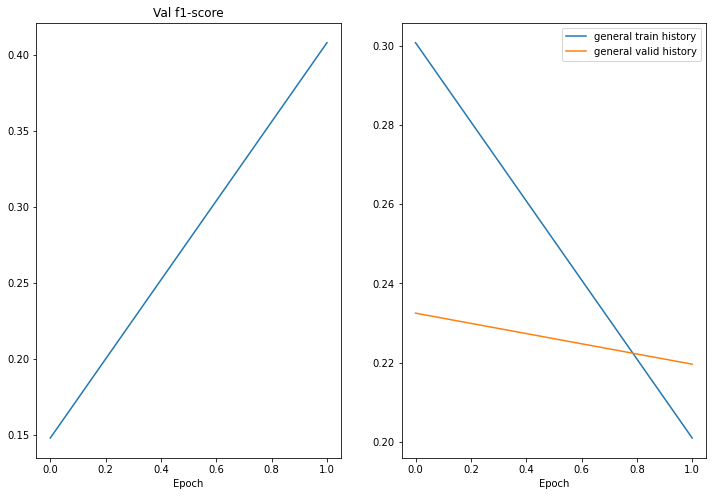

Epoch: 02 | Time: 3m 0s
	Train Loss: 0.201
	 Val. Loss: 0.220 |  Val. F1: 0.408


KeyboardInterrupt: ignored

In [ ]:
for i, (freeze_layer_count, freeze_embeddings_layer) in enumerate(setups):
        setup_path = os.path.join(output_scores_dir, f"exp_{i}/setup_descr.txt")
        for seed in seeds_list:
            experiment_dir = f"exp_{i}/seed_{seed}"
            experiment_dir = os.path.join(output_scores_dir, experiment_dir)
            if not os.path.exists(experiment_dir) and experiment_dir != '':
                os.makedirs(experiment_dir)

            torch.manual_seed(seed)
            torch.random.manual_seed(seed)
            os.environ['PYTHONHASHSEED'] = str(seed)
            random.seed(seed)
            np.random.seed(seed)
            torch.cuda.random.manual_seed(seed)
            torch.cuda.random.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True

            enrudr_model = AutoModel.from_pretrained(text_model_name)
            if freeze_layer_count > 0:
                for layer in enrudr_model.encoder.layer[:freeze_layer_count]:
                    for param in layer.parameters():
                        param.requires_grad = False

            if freeze_embeddings_layer:
                for param in enrudr_model.embeddings.parameters():
                    param.requires_grad = False
            print("#Trainable params: ", sum(p.numel() for p in enrudr_model.parameters() if p.requires_grad))

            bert_simple_clf = BertSimpleClassifier(enrudr_model, dropout=DROPOUT).to(device)
            optimizer = optim.Adam(bert_simple_clf.parameters(), lr=lr)
            criterion = nn.BCEWithLogitsLoss()

            train_evaluate(bert_simple_clf, train_loader, dev_loader, optimizer, criterion, N_EPOCHS, use_drug_embeddings, "ru_simple")
            bert_simple_clf.load_state_dict(torch.load('best-val-ru_simple.pt'))

            true_labels, dev_pred_labels, dev_pred_probas = predict(bert_simple_clf, dev_loader, use_drug_embeddings)
            assert len(dev_pred_labels) == len(true_labels)
            assert len(dev_pred_labels) == len(dev_pred_probas)
            dev_precision = precision_score(true_labels, dev_pred_labels)
            dev_recall = recall_score(true_labels, dev_pred_labels)
            dev_f1 = f1_score(true_labels, dev_pred_labels)

            print(f"{dev_precision},{dev_recall},{dev_f1}")


            true_labels, test_pred_labels, test_pred_probas = predict(bert_simple_clf, test_loader, use_drug_embeddings)
            assert len(test_pred_labels) == len(true_labels)
            assert len(test_pred_labels) == len(test_pred_probas)
            test_precision = precision_score(true_labels, test_pred_labels)
            test_recall = recall_score(true_labels, test_pred_labels)
            test_f1 = f1_score(true_labels, test_pred_labels)
            print(f"{test_precision},{test_recall},{test_f1}")

            exp_scores_path = os.path.join(experiment_dir, "scores.txt")
            with codecs.open(exp_scores_path, 'a+', encoding="utf-8") as out_file:
                out_file.write(f"{seed},{dev_precision},{dev_recall},{dev_f1},{test_precision},{test_recall},{test_f1}\n")

            dev_labels_path = os.path.join(experiment_dir, "dev_labels.txt")
            dev_probas_path = os.path.join(experiment_dir, "dev_probas.txt")
            test_labels_path = os.path.join(experiment_dir, "test_labels.txt")
            test_probas_path = os.path.join(experiment_dir, "test_probas.txt")

            save_labels_probas(dev_labels_path, dev_probas_path, dev_pred_labels, dev_pred_probas)
            save_labels_probas(test_labels_path, test_probas_path, test_pred_labels, test_pred_probas)

            bert_simple_clf = bert_simple_clf.cpu()

            del bert_simple_clf
            del enrudr_model
            del optimizer
            del criterion


In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_simple_clf, dev_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")

In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_simple_clf, test_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")

In [ ]:
raise Exception("")

linear + relu, 0

0.4928571428571429,0.518796992481203,0.5054945054945056

0.43243243243243246,0.4819277108433735,0.45584045584045585

linear + relu, 42

0.47692307692307695,0.46616541353383456,0.47148288973384034

0.474025974025974,0.4397590361445783,0.45625

relu

0.47692307692307695,0.46616541353383456,0.47148288973384034

0.474025974025974,0.4397590361445783,0.45625


0: Precision: 0.5147058823529411
Recall: 0.5263157894736842
F: 0.5204460966542751

0: Precision: 0.4935064935064935
Recall: 0.4578313253012048
F: 0.475

In [ ]:
del bert_simple_clf
del enrudr_model
del optimizer
del criterion

### Берт с драгами

In [ ]:
torch.manual_seed(SEED)

In [ ]:
enrudr_model = AutoModel.from_pretrained(text_model_name)

In [ ]:
N_EPOCHS = 5
DROPOUT = 0.2
drug_enc_hid_dim = enrudr_model.config.hidden_size
use_drug_embeddings = True

In [ ]:
bert_clf_with_drug_embeddings = BertClassifierWithDrugEmbeddings(enrudr_model, drug_enc_hid_dim=drug_enc_hid_dim, dropout=DROPOUT).to(device)
optimizer = optim.Adam(bert_clf_with_drug_embeddings.parameters(), lr=3e-5)
# scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=num_steps_per_epoch * N_EPOCHS,  ) 
criterion = nn.BCEWithLogitsLoss()

In [ ]:
train_evaluate(bert_clf_with_drug_embeddings, train_loader, dev_loader, optimizer, criterion, N_EPOCHS, use_drug_embeddings, "ru_drugs")

In [ ]:
bert_clf_with_drug_embeddings.load_state_dict(torch.load('best-val-ru_drugs.pt'))

In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_clf_with_drug_embeddings, dev_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")

In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_clf_with_drug_embeddings, test_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")

linear + relu, 0

0.4965986394557823,0.5488721804511278,0.5214285714285715

0.4878048780487805,0.4819277108433735,0.48484848484848486

linear + relu, 42

0.46808510638297873,0.49624060150375937,0.48175182481751827

0.4502923976608187,0.463855421686747,0.456973293768546

relu

0.41089108910891087,0.6240601503759399,0.4955223880597015

0.4267241379310345,0.5963855421686747,0.4974874371859296

0: Precision: 0.4095238095238095
Recall: 0.6466165413533834
F: 0.5014577259475218

0: Precision: 0.3902439024390244
Recall: 0.5783132530120482
F: 0.46601941747572817

In [ ]:
del bert_clf_with_drug_embeddings
del enrudr_model
del optimizer
del criterion

### Просто Берт без драгов, двуязыковой трейн

In [ ]:
torch.manual_seed(SEED)

In [ ]:
enrudr_model = AutoModel.from_pretrained(text_model_name)

In [ ]:
N_EPOCHS = 5
DROPOUT = 0.2
drug_enc_hid_dim = enrudr_model.config.hidden_size
use_drug_embeddings = False

In [ ]:
bert_simple_clf = BertSimpleClassifier(enrudr_model, dropout=DROPOUT).to(device)
optimizer = optim.Adam(bert_simple_clf.parameters(), lr=3e-5)
# scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=num_steps_per_epoch * N_EPOCHS,  ) 
criterion = nn.BCEWithLogitsLoss()

In [ ]:
train_evaluate(bert_simple_clf, bilingual_train_loader, dev_loader, optimizer, criterion, N_EPOCHS, use_drug_embeddings, "ruen_simple")

In [ ]:
bert_simple_clf.load_state_dict(torch.load('best-val-ruen_simple.pt'))

In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_simple_clf, dev_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")
# print(f"Recall: {recall_score(true_labels, pred_labels)}")
# print(f"F: {f1_score(true_labels, pred_labels)}")
# print(classification_report(true_labels, pred_labels))

In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_simple_clf, test_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")
# print(f"Recall: {recall_score(true_labels, pred_labels)}")
# print(f"F: {f1_score(true_labels, pred_labels)}")

0: Precision: 0.45930232558139533
Recall: 0.5939849624060151
F: 0.5180327868852458

0: Precision: 0.42920353982300885
Recall: 0.5843373493975904
F: 0.4948979591836735

In [ ]:
del bert_simple_clf
del enrudr_model
del optimizer
del criterion

### Берт с драгами, двуязыковой трейн

In [ ]:
torch.manual_seed(SEED)

In [ ]:
enrudr_model = AutoModel.from_pretrained(text_model_name)

In [ ]:
N_EPOCHS = 5
DROPOUT = 0.2
drug_enc_hid_dim = enrudr_model.config.hidden_size
use_drug_embeddings = True

In [ ]:
bert_clf_with_drug_embeddings = BertClassifierWithDrugEmbeddings(enrudr_model, drug_enc_hid_dim=drug_enc_hid_dim, dropout=DROPOUT).to(device)
optimizer = optim.Adam(bert_clf_with_drug_embeddings.parameters(), lr=3e-5)
# scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=num_steps_per_epoch * N_EPOCHS,  ) 
criterion = nn.BCEWithLogitsLoss()

In [ ]:
train_evaluate(bert_clf_with_drug_embeddings, bilingual_train_loader, dev_loader, optimizer, criterion, N_EPOCHS, use_drug_embeddings, "ruen_drugs")

In [ ]:
bert_clf_with_drug_embeddings.load_state_dict(torch.load('best-val-ruen_drugs.pt'))

In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_clf_with_drug_embeddings, dev_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")
# print(f"Recall: {recall_score(true_labels, pred_labels)}")
# print(f"F: {f1_score(true_labels, pred_labels)}")

In [ ]:
true_labels, pred_labels, pred_probas = predict(bert_clf_with_drug_embeddings, test_loader, use_drug_embeddings)
print(f"{precision_score(true_labels, pred_labels)},{recall_score(true_labels, pred_labels)},{f1_score(true_labels, pred_labels)}")
# print(f"Recall: {recall_score(true_labels, pred_labels)}")
# print(f"F: {f1_score(true_labels, pred_labels)}")

In [ ]:
del bert_clf_with_drug_embeddings
del enrudr_model
del optimizer
del criterion

**Simple**

42 : dev 0.4432,0.61654,0.5157

42 : test,0.4311,0.5662,0.4895

0: 0.4461,0.6541,0.5304

0: 0.4349,0.5843,0.4987

21: 0.3775,0.7067,0.4921

21: 0.3714,0.7048,0.4864

13: 0.5038,0.4887,0.49618

13: 0.5070,0.4337,0.4675

17: 0.5267,0.4436,0.4816

17: 0.4926,0.4036,0.4437

67: 0.4771,0.5488,0.5104

67: 0.4364,0.4759,0.4553

**+ Drugs**

42: dev,0.4560,0.6240,0.52698

42: test,0.4303,0.61445,0.5062

0:  0.4213,0.6240,0.5030

0: 0.4474,0.5903,0.5090

21: 0.5071,0.5338,0.5201

21:  0.4939,0.4939,0.4939

13:0.4195,0.6466,0.5088

13: 0.4398,0.6385,0.5208

17: 0.4575,0.5263,0.4895

17: 0.5,0.5240,0.5117

67: 0.4675,0.5413,0.5017

67: 0.4504,0.5481,0.4945

**Bilingual simple**

42: 0.4766,0.6917,0.5644

42: 0.4237,0.6024,0.4975

0: 0.4691,0.5714,0.5152

0: 0.4423,0.5783,0.5013

21: 0.5865,0.4586,0.5147

21: 0.5645,0.4216,0.48275

13: 0.6285,0.4962,0.5546

13: 0.5737,0.4216,0.48611

17: 0.5,0.6616,0.5695

17: 0.4347,0.6024,0.5050

67: 0.5234,0.5864,0.5531

67: 0.4925,0.5963,0.5395

**Bilingual + drugs**

42:
0.44776,0.6766,0.53892

42: 0.42016,0.6024,0.4950

0: 0.5725,0.5338,0.5525

0: 0.5256,0.49397,0.50931

21: 0.4311,0.7067,0.5356

21: 0.4041,0.6987,0.51214


13: 0.5479,0.6015,0.5734767025089605

13: 0.4810,0.5361,0.5071225071225072

17:0.5504,0.4511,0.4958

17: 0.5,0.4036,0.4466

67: 0.5230,0.5112,0.5171

67: 0.5031,0.4759,0.4891
